<a href="https://colab.research.google.com/github/varun1271/DSA0203-COMPUTER-VISION/blob/main/CO4_AT1_192424230.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
NAME: Y.VARUN KUMAR REDDY
REG NO:192424230

In [ ]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
!pip install -q opencv-contrib-python-headless==5.0.0.93

Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 9.6 MB/s eta 0:00:00


In [ ]:
!pip install -q opencv-contrib-python-headless==4.13.0.92

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 9.2 MB/s eta 0:00:00


In [ ]:
import cv2

print("OpenCV Version:", cv2.__version__)
print("CascadeClassifier:", hasattr(cv2, "CascadeClassifier"))

OpenCV Version: 4.13.0
CascadeClassifier: True


Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (6).jpeg
Detected Faces: 0
True Positive: 0
False Positive: 0
False Negative: 1
Precision: 0
Recall: 0.0
F1-Score: 0


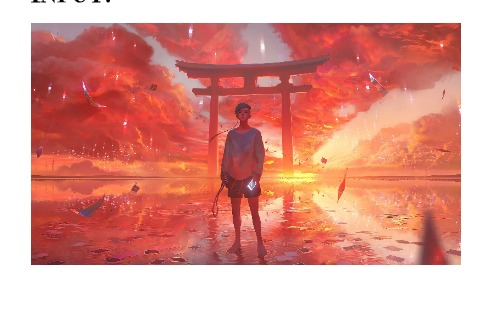

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))
img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5
)

detected = len(faces)

# Ground truth: number of faces actually present
# Change this according to your image
ground_truth = 1

TP = min(detected, ground_truth)
FP = max(0, detected - ground_truth)
FN = max(0, ground_truth - detected)

precision = TP / (TP + FP) if TP + FP > 0 else 0
recall = TP / (TP + FN) if TP + FN > 0 else 0

if precision + recall > 0:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = 0

print("Detected Faces:", detected)
print("True Positive:", TP)
print("False Positive:", FP)
print("False Negative:", FN)
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-Score:", round(f1, 2))

for (x, y, w, h) in faces:
    cv2.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

cv2_imshow(img)

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.9 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (7).jpeg

image 1/1 /content/WhatsApp Image 2026-07-21 at 1.52.57 PM (7).jpeg: 416x640 1 person, 334.7ms
Speed: 4.0ms preprocess, 334.7ms inference, 35.5ms postprocess per image at shape (1, 3, 416, 640)
Detected Objects:
person Confidence: 0.73


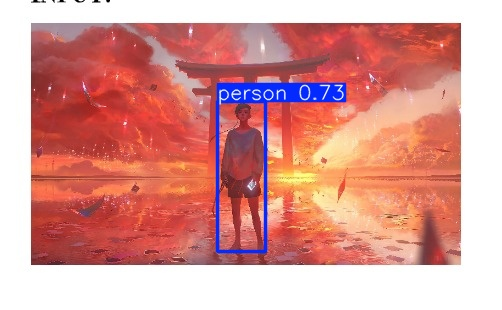

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display

uploaded = files.upload()

filename = next(iter(uploaded))

model = YOLO("yolo11n.pt")

results = model(
    filename,
    conf=0.25,
    iou=0.45
)

for result in results:

    print("Detected Objects:")

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            model.names[class_id],
            "Confidence:",
            round(confidence, 2)
        )

    result.save(filename="yolo_output.jpg")

display(Image("yolo_output.jpg"))

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (8).jpeg
Viola-Jones Faces: 0
YOLO Objects: 1


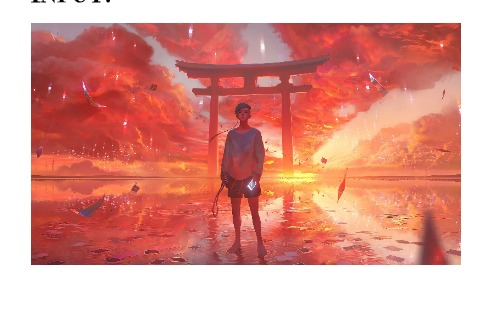

In [ ]:
import cv2
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename)

# -------------------------
# Viola-Jones
# -------------------------

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = cascade.detectMultiScale(
    gray,
    1.1,
    5
)

print("Viola-Jones Faces:", len(faces))

# -------------------------
# YOLO
# -------------------------

model = YOLO("yolo11n.pt")

results = model(
    filename,
    verbose=False
)

yolo_count = 0

for result in results:
    yolo_count = len(result.boxes)

print("YOLO Objects:", yolo_count)

# Display Viola-Jones result

for (x, y, w, h) in faces:

    cv2.rectangle(
        img,
        (x, y),
        (x+w, y+h),
        (0, 255, 0),
        2
    )

cv2_imshow(img)

Intersection Area: 14400
Union Area: 27700
IoU: 0.52


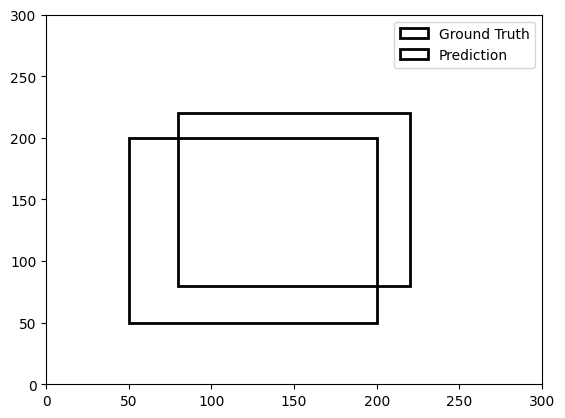

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Ground truth box
ground_truth = [50, 50, 200, 200]

# Predicted box
prediction = [80, 80, 220, 220]

# Intersection
x1 = max(ground_truth[0], prediction[0])
y1 = max(ground_truth[1], prediction[1])

x2 = min(ground_truth[2], prediction[2])
y2 = min(ground_truth[3], prediction[3])

intersection = max(0, x2-x1) * max(0, y2-y1)

# Areas
area_gt = (
    (ground_truth[2] - ground_truth[0]) *
    (ground_truth[3] - ground_truth[1])
)

area_prediction = (
    (prediction[2] - prediction[0]) *
    (prediction[3] - prediction[1])
)

# Union
union = area_gt + area_prediction - intersection

# IoU
iou = intersection / union

print("Intersection Area:", intersection)
print("Union Area:", union)
print("IoU:", round(iou, 3))

# Draw boxes
fig, ax = plt.subplots()

rect1 = patches.Rectangle(
    (50, 50),
    150,
    150,
    fill=False,
    linewidth=2,
    label="Ground Truth"
)

rect2 = patches.Rectangle(
    (80, 80),
    140,
    140,
    fill=False,
    linewidth=2,
    label="Prediction"
)

ax.add_patch(rect1)
ax.add_patch(rect2)

ax.set_xlim(0, 300)
ax.set_ylim(0, 300)

ax.legend()
plt.show()

Saving V_992.mp4 to V_992 (1).mp4
Tracked Points: 25


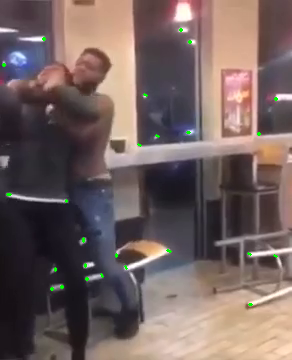

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

cap = cv2.VideoCapture(filename)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

if not ret:
    print("Video could not be read.")
else:

    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    points = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=50,
        qualityLevel=0.3,
        minDistance=7
    )

    if points is not None:

        new_points, status, error = cv2.calcOpticalFlowPyrLK(
            gray1,
            gray2,
            points,
            None
        )

        good_old = points[status == 1]
        good_new = new_points[status == 1]

        print("Tracked Points:", len(good_new))

        for old, new in zip(good_old, good_new):

            x1, y1 = old.ravel()
            x2, y2 = new.ravel()

            cv2.arrowedLine(
                frame2,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (0, 255, 0),
                2
            )

        cv2_imshow(frame2)

    else:
        print("No feature points found.")

cap.release()

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (10).jpeg
Frames Processed: 1


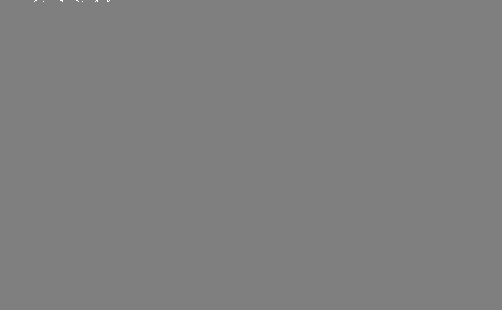

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

cap = cv2.VideoCapture(filename)

gmm = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=50,
    detectShadows=True
)

mask = None
count = 0

while count < 30:

    ret, frame = cap.read()

    if not ret:
        break

    mask = gmm.apply(frame)

    count += 1

print("Frames Processed:", count)

if mask is not None:
    cv2_imshow(mask)
else:
    print("No frames found.")

cap.release()

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (11).jpeg
Frames Processed: 1
Average Foreground Percentage: 0.01 %


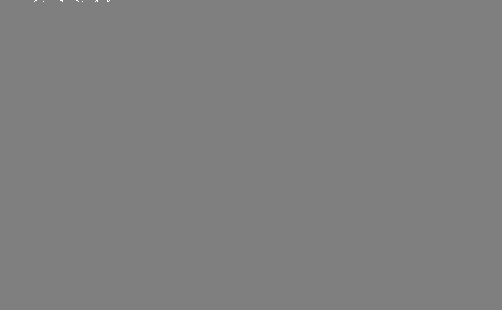

In [ ]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

cap = cv2.VideoCapture(filename)

gmm = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=50
)

total_frames = 0
foreground_percentage = []

while total_frames < 30:

    ret, frame = cap.read()

    if not ret:
        break

    mask = gmm.apply(frame)

    foreground = np.sum(mask > 200)

    percentage = (
        foreground / mask.size
    ) * 100

    foreground_percentage.append(percentage)

    total_frames += 1

cap.release()

if total_frames > 0:

    average = np.mean(foreground_percentage)

    print("Frames Processed:", total_frames)

    print(
        "Average Foreground Percentage:",
        round(average, 2),
        "%"
    )

    cv2_imshow(mask)

else:
    print("No video frames found.")

Saving V_992.mp4 to V_992.mp4
Motion Vectors: 25


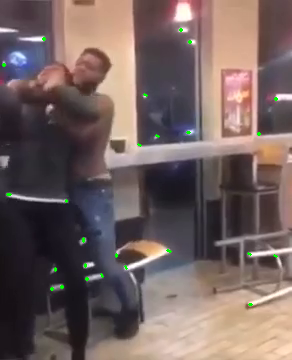

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

cap = cv2.VideoCapture(filename)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

if not ret:
    print("Video could not be read.")
else:

    gray1 = cv2.cvtColor(
        frame1,
        cv2.COLOR_BGR2GRAY
    )

    gray2 = cv2.cvtColor(
        frame2,
        cv2.COLOR_BGR2GRAY
    )

    points = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=50,
        qualityLevel=0.3,
        minDistance=7
    )

    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        gray1,
        gray2,
        points,
        None
    )

    old_points = points[status == 1]
    new_points = new_points[status == 1]

    print("Motion Vectors:", len(new_points))

    for old, new in zip(old_points, new_points):

        x1, y1 = old.ravel()
        x2, y2 = new.ravel()

        cv2.arrowedLine(
            frame2,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            2
        )

    cv2_imshow(frame2)

cap.release()

In [ ]:
import numpy as np

# Actual image points
actual = np.array([
    [100, 100],
    [200, 150],
    [300, 200],
    [400, 250]
])

# Projected image points
projected = np.array([
    [105, 103],
    [198, 152],
    [302, 197],
    [397, 254]
])

errors = np.sqrt(
    np.sum(
        (actual - projected) ** 2,
        axis=1
    )
)

print("Reprojection Errors:")

for i, error in enumerate(errors):
    print(
        "Point",
        i + 1,
        ":",
        round(error, 2)
    )

mean_error = np.mean(errors)

print(
    "\nMean Reprojection Error:",
    round(mean_error, 2)
)

Reprojection Errors:
Point 1 : 5.83
Point 2 : 2.83
Point 3 : 3.61
Point 4 : 5.0

Mean Reprojection Error: 4.32


Saving V_992.mp4 to V_992 (2).mp4
Sparse Optical Flow Points: 25
Dense Optical Flow calculated.
Total Dense Flow Pixels: 105120


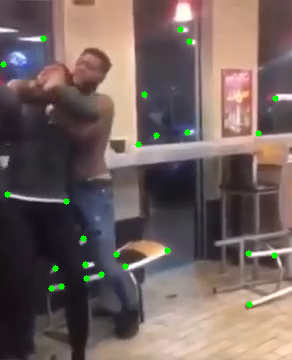

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

cap = cv2.VideoCapture(filename)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

if not ret:
    print("Video could not be read.")
else:

    gray1 = cv2.cvtColor(
        frame1,
        cv2.COLOR_BGR2GRAY
    )

    gray2 = cv2.cvtColor(
        frame2,
        cv2.COLOR_BGR2GRAY
    )

    # Sparse Optical Flow
    points = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=50,
        qualityLevel=0.3,
        minDistance=7
    )

    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        gray1,
        gray2,
        points,
        None
    )

    good_points = new_points[status == 1]

    print(
        "Sparse Optical Flow Points:",
        len(good_points)
    )

    # Dense Optical Flow
    flow = cv2.calcOpticalFlowFarneback(
        gray1,
        gray2,
        None,
        0.5,
        3,
        15,
        3,
        5,
        1.2,
        0
    )

    print(
        "Dense Optical Flow calculated."
    )

    print(
        "Total Dense Flow Pixels:",
        flow.shape[0] * flow.shape[1]
    )

    # Display sparse points
    output = frame2.copy()

    for point in good_points:

        x, y = point.ravel()

        cv2.circle(
            output,
            (int(x), int(y)),
            3,
            (0, 255, 0),
            -1
        )

    cv2_imshow(output)

cap.release()

Saving WhatsApp Image 2026-07-21 at 1.52.57 PM.jpeg to WhatsApp Image 2026-07-21 at 1.52.57 PM (14).jpeg
Faces Detected: 0
Detection Time: 0.1123 seconds
Approximate FPS: 8.9


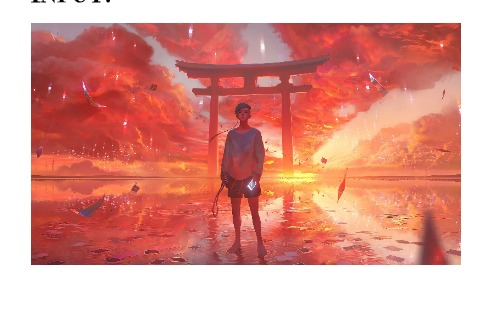

In [ ]:
import cv2
import time
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

start = time.time()

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5
)

end = time.time()

detection_time = end - start

print("Faces Detected:", len(faces))

print(
    "Detection Time:",
    round(detection_time, 4),
    "seconds"
)

if detection_time > 0:

    fps = 1 / detection_time

    print(
        "Approximate FPS:",
        round(fps, 2)
    )

for (x, y, w, h) in faces:

    cv2.rectangle(
        img,
        (x, y),
        (x+w, y+h),
        (0, 255, 0),
        2
    )

cv2_imshow(img)

Confusion Matrix:
[[2 1 0]
 [0 2 1]
 [1 0 2]]


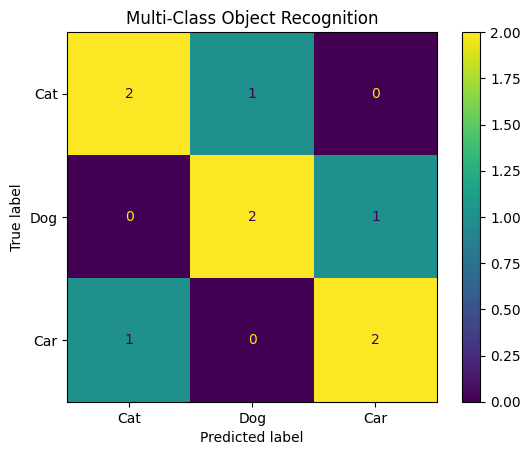

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

actual = [
    "Cat", "Cat", "Cat",
    "Dog", "Dog", "Dog",
    "Car", "Car", "Car"
]

predicted = [
    "Cat", "Cat", "Dog",
    "Dog", "Dog", "Car",
    "Car", "Cat", "Car"
]

classes = [
    "Cat",
    "Dog",
    "Car"
]

cm = confusion_matrix(
    actual,
    predicted,
    labels=classes
)

print("Confusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

display.plot()

plt.title(
    "Multi-Class Object Recognition"
)

plt.show()